In [1]:
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler

# 1. Load the legitimate training data
train_path = os.path.join("data", "processed", "train_legit.csv")
train_df = pd.read_csv(train_path)

# 2. Initialize the scaler and fit_transform the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df)

print(f"Data loaded and scaled. Shape: {X_train_scaled.shape}")

Data loaded and scaled. Shape: (170524, 30)


Training GMMs... This will take a few minutes.
Completed k=1
Completed k=2
Completed k=3
Completed k=4
Completed k=5
Completed k=6
Completed k=7
Completed k=8
Completed k=9
Completed k=10


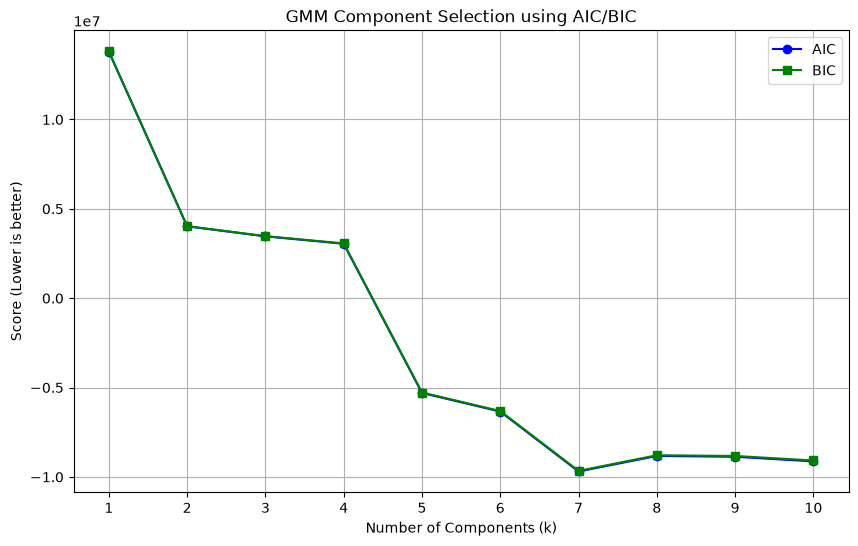

In [2]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

n_components_range = np.arange(1, 11)
aic_scores = []
bic_scores = []

print("Training GMMs... This will take a few minutes.")

for n in n_components_range:
    # Initialize GMM. covariance_type='full' is standard, random_state ensures reproducibility.
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_train_scaled)
    
    aic_scores.append(gmm.aic(X_train_scaled))
    bic_scores.append(gmm.bic(X_train_scaled))
    print(f"Completed k={n}")

# Plotting the AIC and BIC curves
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, aic_scores, marker='o', label='AIC', color='blue')
plt.plot(n_components_range, bic_scores, marker='s', label='BIC', color='green')
plt.xlabel('Number of Components (k)')
plt.ylabel('Score (Lower is better)')
plt.title('GMM Component Selection using AIC/BIC')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)
plt.show()

Training final GMM with k=7...


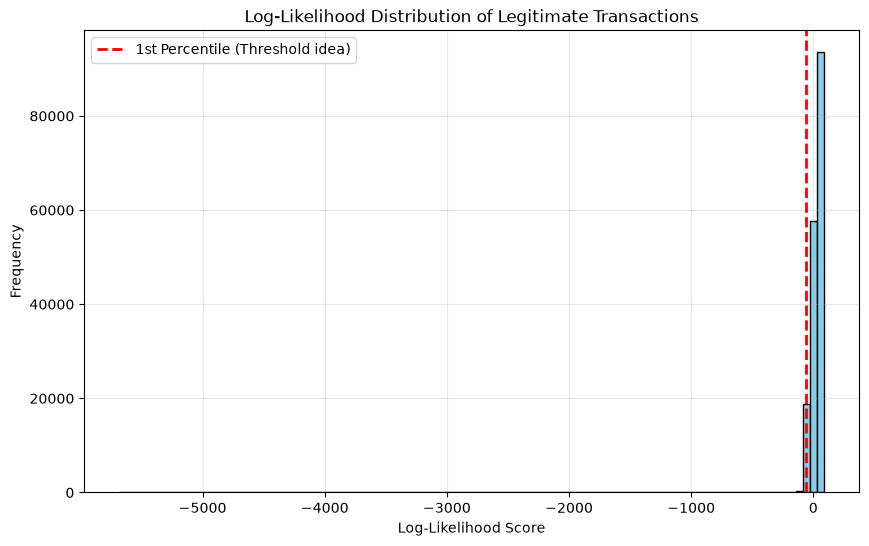

Minimum score in normal data: -5680.54


In [3]:
# Train the final model with our optimal k=7
print("Training final GMM with k=7...")
best_gmm = GaussianMixture(n_components=7, covariance_type='full', random_state=42)
best_gmm.fit(X_train_scaled)

# Get log-likelihood scores for the legitimate training data
# Note: score_samples returns log-likelihood (higher is more "normal")
train_log_likelihood = best_gmm.score_samples(X_train_scaled)

# Plot the distribution of normal transaction scores
plt.figure(figsize=(10, 6))
plt.hist(train_log_likelihood, bins=100, color='skyblue', edgecolor='black')
plt.title('Log-Likelihood Distribution of Legitimate Transactions')
plt.xlabel('Log-Likelihood Score')
plt.ylabel('Frequency')
plt.axvline(np.percentile(train_log_likelihood, 1), color='red', linestyle='dashed', linewidth=2, label='1st Percentile (Threshold idea)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Minimum score in normal data: {train_log_likelihood.min():.2f}")

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the validation dataset
val_path = os.path.join("data", "processed", "val.csv")
val_df = pd.read_csv(val_path)

# 2. Separate features and target
y_val = val_df["Class"]
X_val = val_df.drop(columns=["Class"])

# 3. Scale using the ALREADY TRAINED scaler (do not use fit_transform here!)
X_val_scaled = scaler.transform(X_val)

# 4. Get log-likelihood scores for the validation set
val_scores = best_gmm.score_samples(X_val_scaled)

# 5. Define threshold at the 1st percentile of the TRAINING scores
threshold = np.percentile(train_log_likelihood, 1)
print(f"Calculated Threshold (1st Percentile): {threshold:.2f}\n")

# 6. Predict: If a score is lower than the threshold, flag it as fraud (1)
y_pred = (val_scores < threshold).astype(int)

# 7. Evaluate the performance
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Calculated Threshold (1st Percentile): -58.66

Confusion Matrix:
[[55584  1320]
 [   12    45]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56904
           1       0.03      0.79      0.06        57

    accuracy                           0.98     56961
   macro avg       0.52      0.88      0.53     56961
weighted avg       1.00      0.98      0.99     56961

